In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyprojroot import here
import scipy.stats as stats

# Data Visualisation Notebook

This notebook explores relationships between variables in the merged dataset using visualisations.

## Load and Preview Data
The following code loads the merged dataset and displays the first few rows.

In [3]:
df = pd.read_csv(here("data/processed/merged_data.csv"))

df["datetime"] = pd.to_datetime(df["datetime"])

df.head()

,datetime,cases,passengers,PYPL
0,2020-01-01,1.0,6099370.0,113.62
1,2020-02-01,69.0,5442081.0,117.02
2,2020-03-01,32858.0,3106845.0,99.96
3,2020-04-01,118408.0,206600.0,108.35
4,2020-05-01,68273.0,228018.0,141.56


## Plotting Functions
Helper functions for dual-axis and scatter plots are defined below.

In [4]:
def plot_dual_axis(df, y1, y2):

    ax1_color="tab:blue"
    ax2_color="tab:orange"
    x = "datetime"

    fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))

    ax1.plot(df[x], df[y1], color=ax1_color, marker="s", markersize=5, alpha=0.9)
    ax1.set_ylabel(y1, color=ax1_color)
    ax1.tick_params(axis="y", labelcolor=ax1_color)

    ax2 = ax1.twinx()
    ax2.plot(df[x], df[y2], color=ax2_color, marker="o", markersize=5, alpha=0.9)
    ax2.set_ylabel(y2, color=ax2_color)
    ax2.tick_params(axis="y", labelcolor=ax2_color)

    title = f"{y1} & {y2} over time"

    ax1.grid(alpha=0.3)
    fig.tight_layout()
    fig.suptitle(title, fontsize=14)

    fig.savefig(here(f"figures/{title}.png"))

    return fig, ax1, ax2


In [5]:
def plot_scatter(df, x_col, y_col):

    x, y = df[x_col], df[y_col]

    spr, p = stats.spearmanr(x, y)
    corr_text = f"Spearman r = {spr:.3f}, p = {p:.3f}"

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    ax.scatter(x, y, alpha=0.9)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    if p < 0.05: # type: ignore
        coeffs = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = np.polyval(coeffs, x_line)
        ax.plot(x_line, y_line, color="red", linestyle="--", linewidth=1.5)

    ax.annotate(
        corr_text,
        xy=(0.95, 0.95),
        xycoords="axes fraction",
        fontsize=12,
        ha="right",
        va="top",
        bbox=dict(boxstyle="round, pad=0.3", fc="#f9f9f9", ec="black", lw=1),
    )

    title = f"{y_col} vs {x_col} with Spearman r"
    ax.grid(alpha=0.3)
    plt.title(title, fontsize=14)
    fig.tight_layout()

    fig.savefig(here(f"figures/{title}.png"))

    return fig, ax

## Plots

### Cases vs Passengers

(<Figure size 800x500 with 2 Axes>,
 <Axes: ylabel='cases'>,
 <Axes: ylabel='passengers'>)

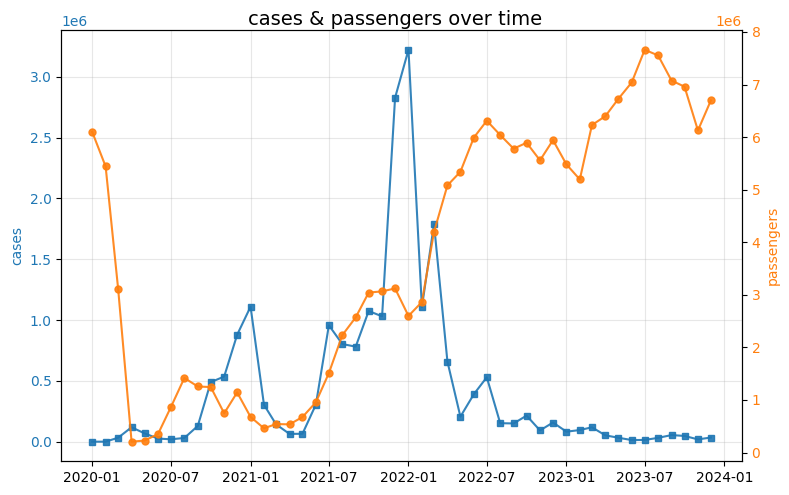

In [6]:
plot_dual_axis(df, "cases", "passengers")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'passengers vs cases with Spearman r'}, xlabel='cases', ylabel='passengers'>)

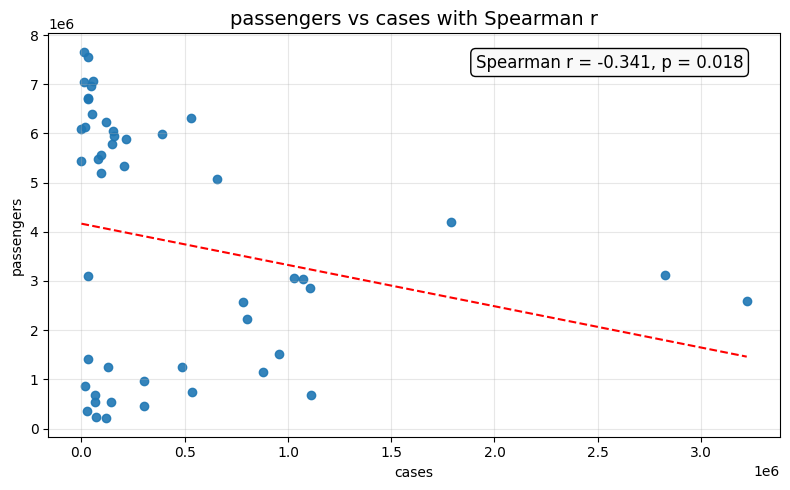

In [7]:
plot_scatter(df, "cases", "passengers")

## Cases vs Stock

(<Figure size 800x500 with 2 Axes>,
 <Axes: ylabel='cases'>,
 <Axes: ylabel='PYPL'>)

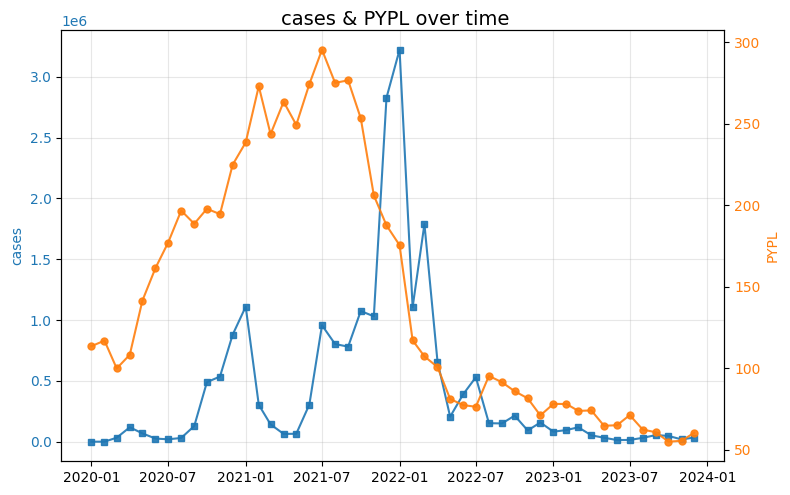

In [8]:
plot_dual_axis(df, "cases", "PYPL")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'PYPL vs cases with Spearman r'}, xlabel='cases', ylabel='PYPL'>)

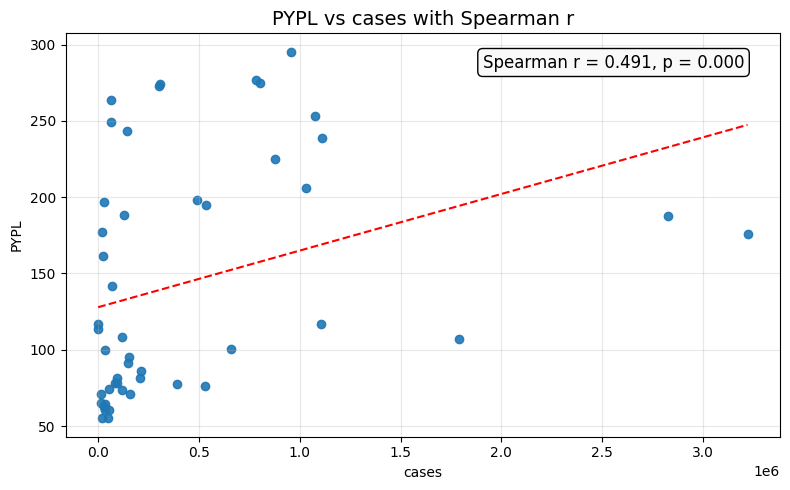

In [9]:
plot_scatter(df, "cases", "PYPL")

## Passengers vs Stock

(<Figure size 800x500 with 2 Axes>,
 <Axes: ylabel='passengers'>,
 <Axes: ylabel='PYPL'>)

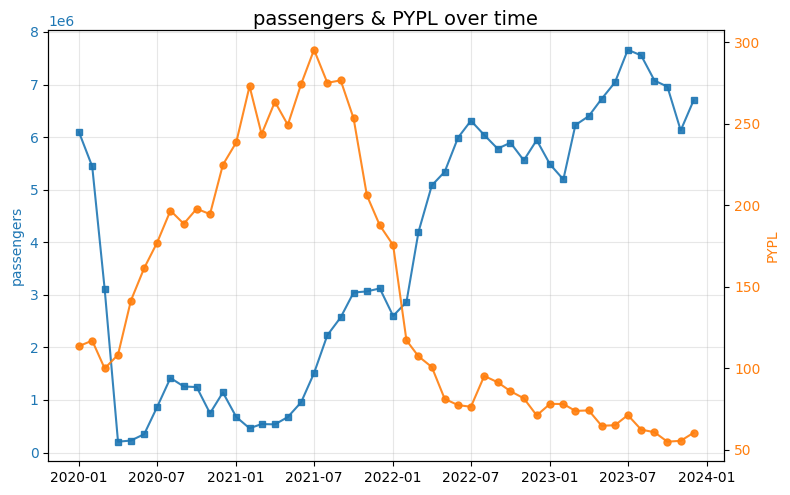

In [10]:
plot_dual_axis(df, "passengers", "PYPL")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'PYPL vs passengers with Spearman r'}, xlabel='passengers', ylabel='PYPL'>)

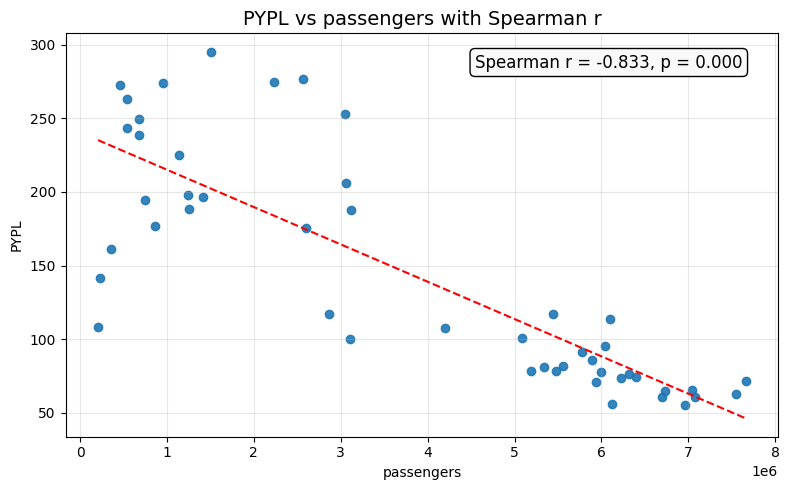

In [11]:
plot_scatter(df, "passengers", "PYPL")